In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Set the random seed for reproducibility
np.random.seed(42)

In [6]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Normal salaries
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [7]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,161.335385,61.602782,32872.298269
1,173.937504,64.006074,45735.166345
2,179.118220,48.761043,41130.287935
3,176.966943,64.742450,124436.686502
4,170.641103,62.408673,56830.587073


In [8]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,176.235849,70.459558,66984.723516
std,8.193092,14.636881,138216.028794
min,150.000000,40.000000,13512.118115
25%,171.358232,61.456050,26313.930854
50%,175.681352,69.241004,34313.579085
75%,179.788005,77.130967,45653.512610
max,210.000000,130.000000,1000000.000000


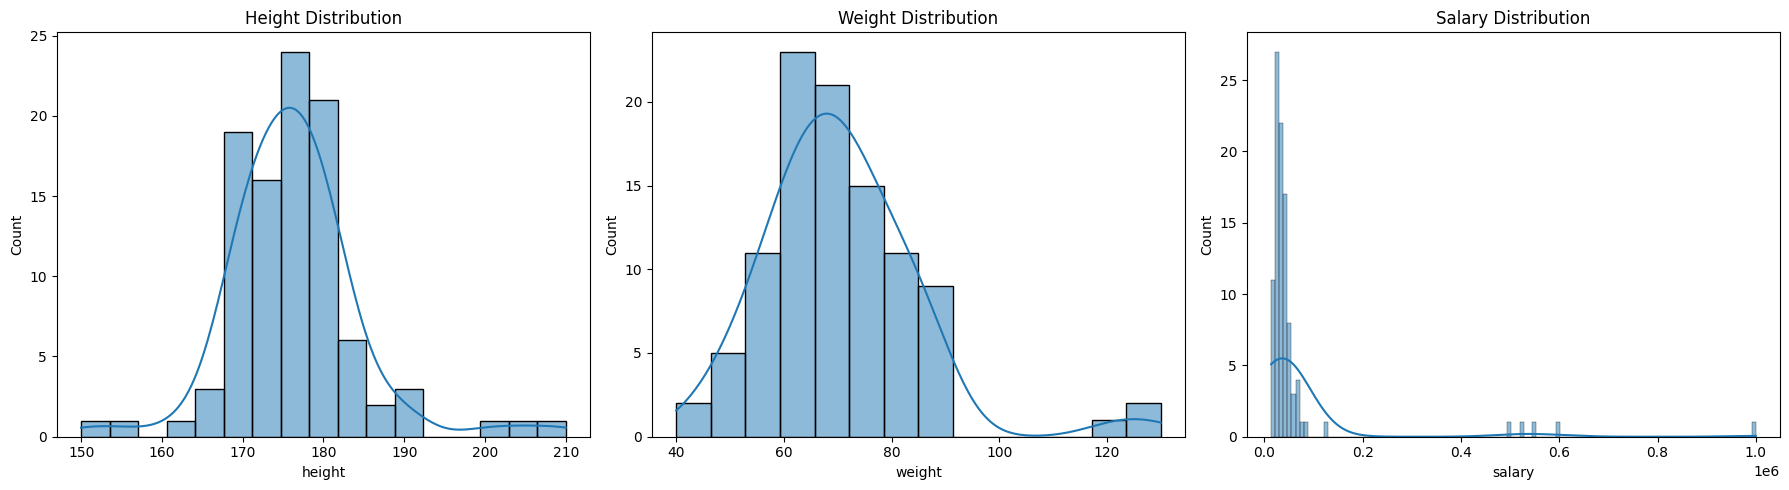

In [9]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

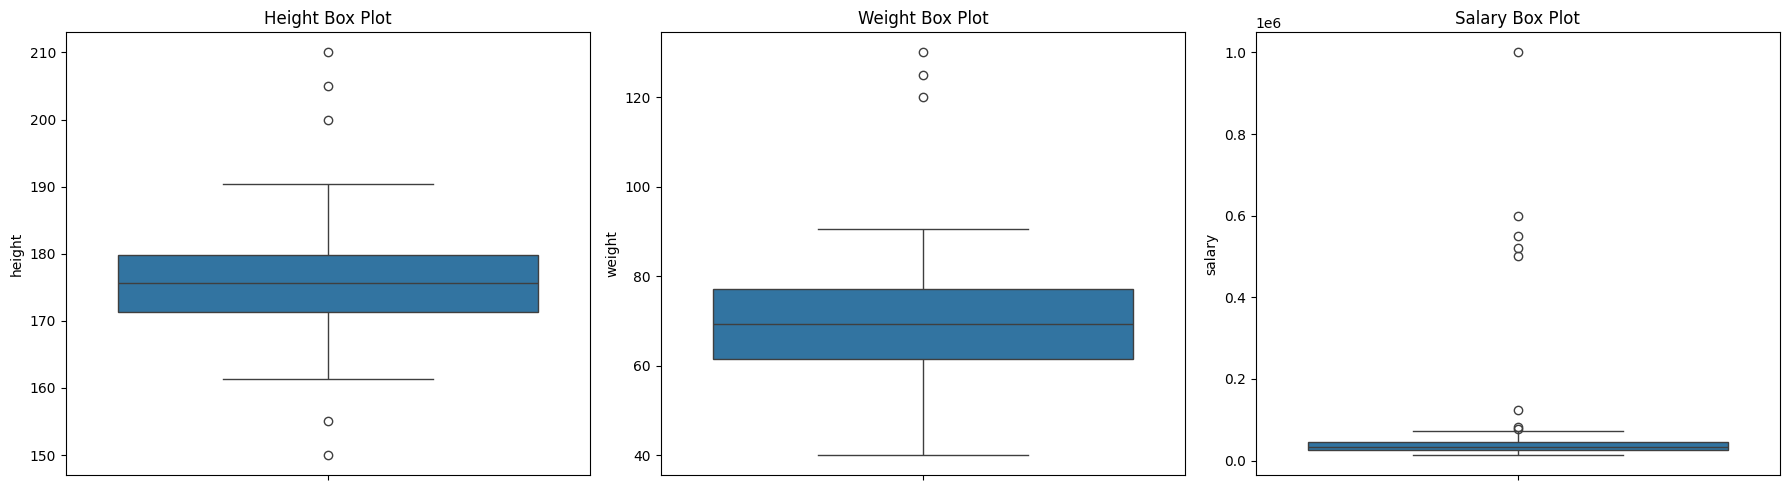

In [10]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

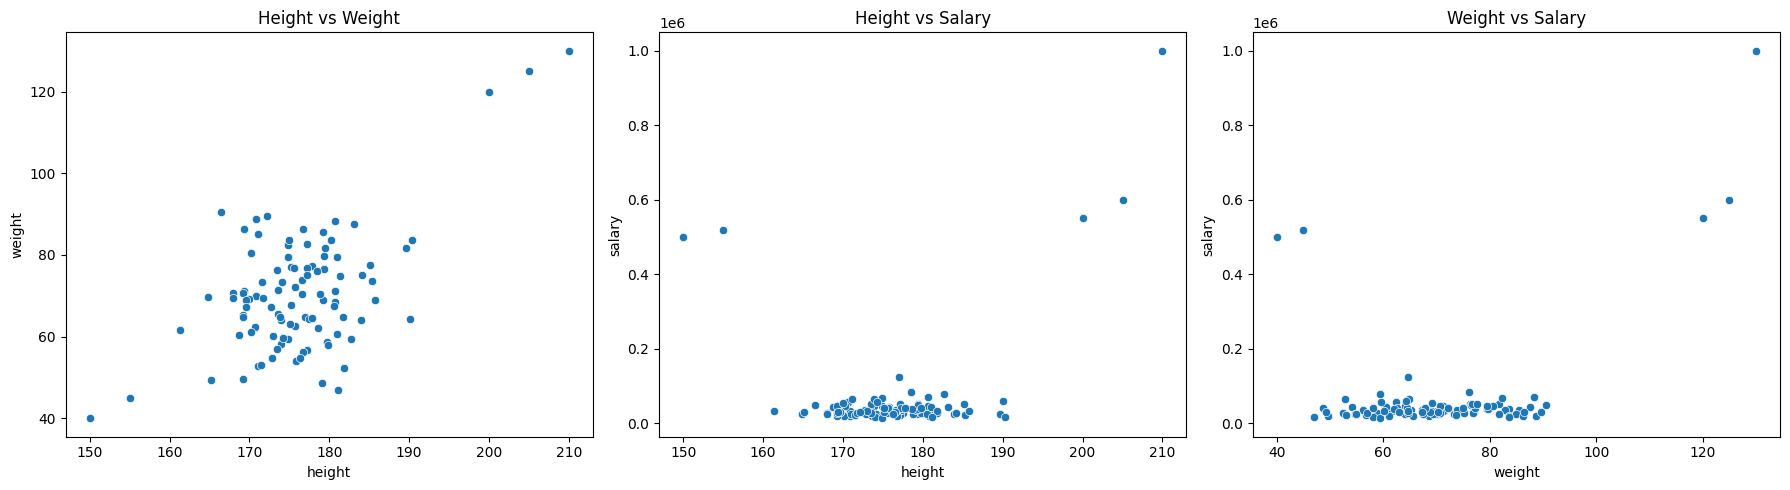

In [11]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [12]:
# Define function for Z-score outlier detection
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]


In [ ]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 3 found at indices [95 98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [14]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [15]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 5 found at indices [95 96 97 98 99]
Weight outliers (IQR): 3 found at indices [97 98 99]
Salary outliers (IQR): 8 found at indices [ 3 26 86 95 96 97 98 99]


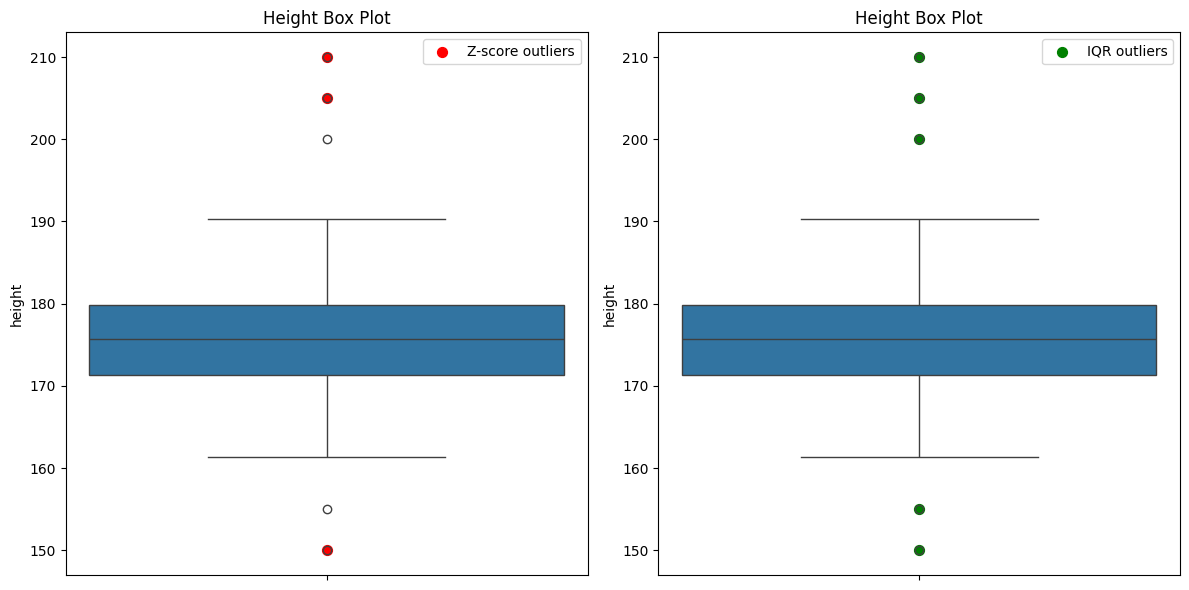

In [16]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 176.24, std: 8.19
Weight mean: 70.46, std: 14.64
Salary mean: 66984.72, std: 138216.03


In [18]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 175.71, std: 5.65
Weight mean: 69.41, std: 10.67
Salary mean: 35247.76, std: 12517.77


In [19]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
def winsorize(data, limits=(0.05, 0.05)):
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [20]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])


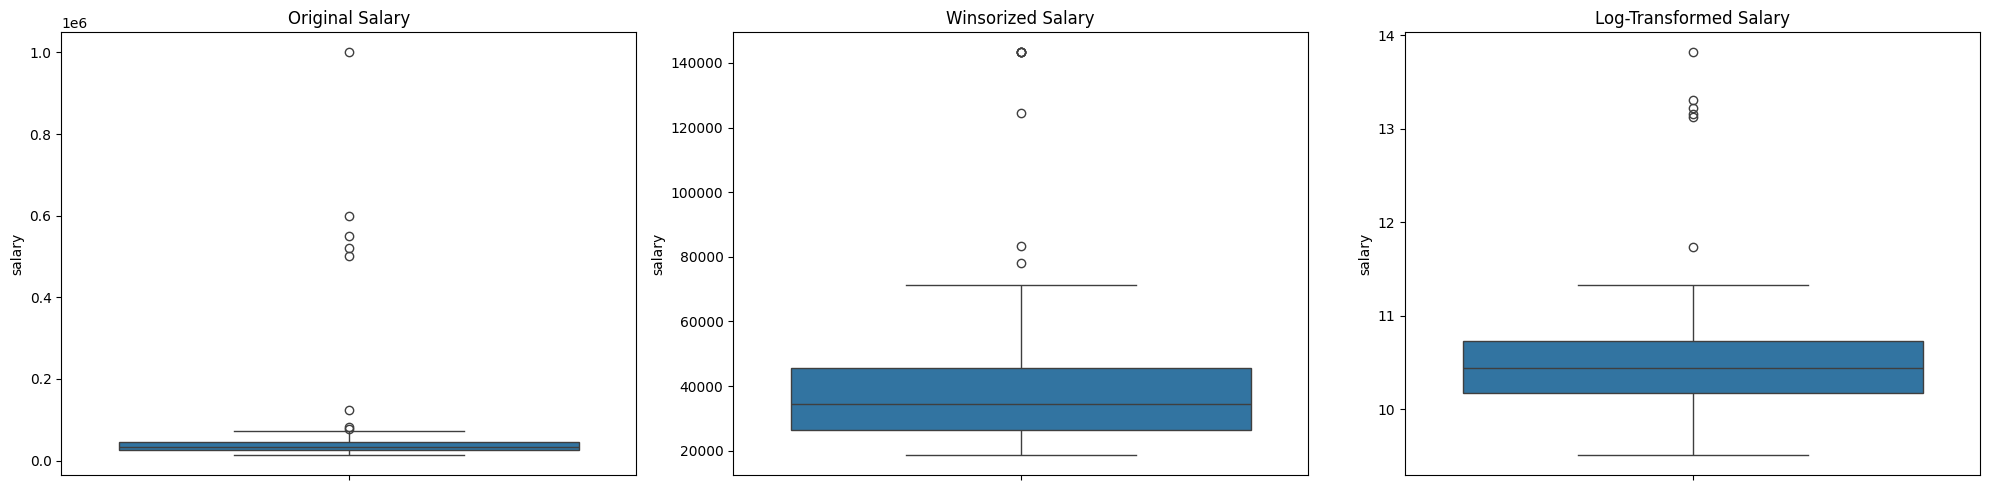

In [21]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [22]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


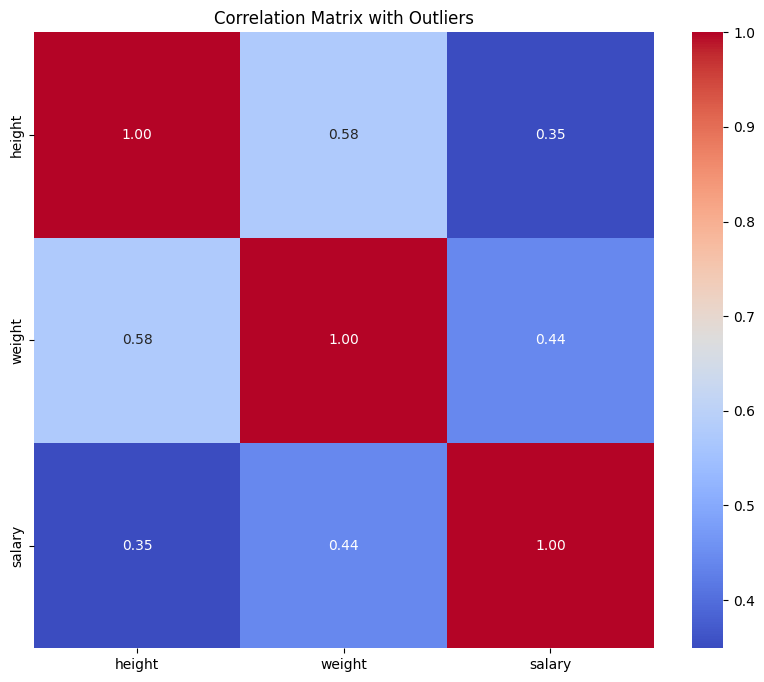

In [23]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


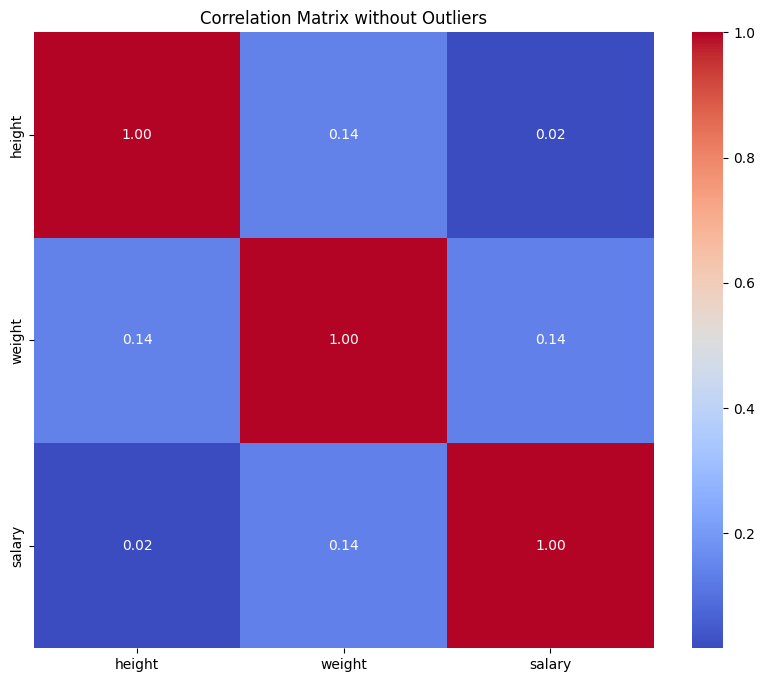

In [24]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()


In [25]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [26]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,176.235849,175.681352,8.193092,150.000000,210.0,60.000000,8.429774,0.885968,4.381269,0.0,0.0,3.0,3.0,5.0,5.0
weight,100.0,70.459558,69.241004,14.636881,40.000000,130.0,90.000000,15.674918,1.356644,3.992399,0.0,0.0,3.0,3.0,3.0,3.0
salary,100.0,66984.723516,34313.579085,138216.028794,13512.118115,1000000.0,986487.881885,19339.581756,4.792581,24.129854,0.0,0.0,5.0,5.0,8.0,8.0


In [27]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [28]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


Multivariate outliers: 0 found at indices []


<Figure size 1200x1000 with 0 Axes>

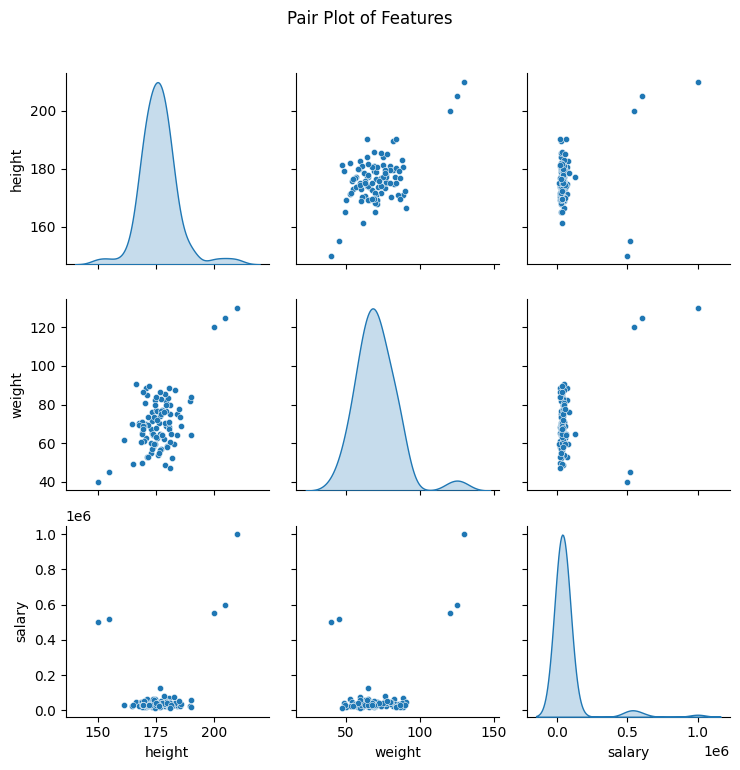

In [29]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2637/3117540217.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


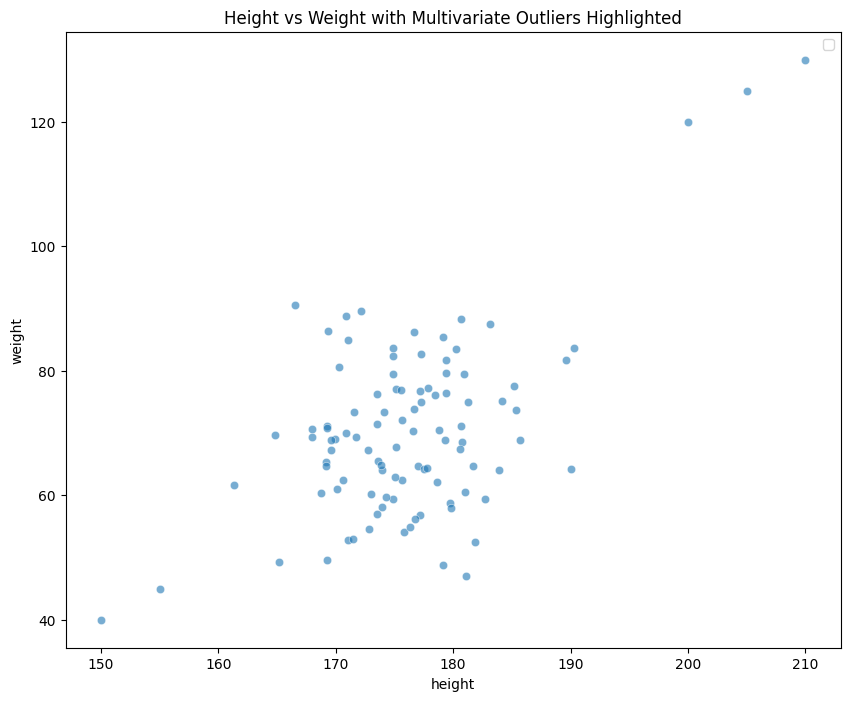

In [30]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


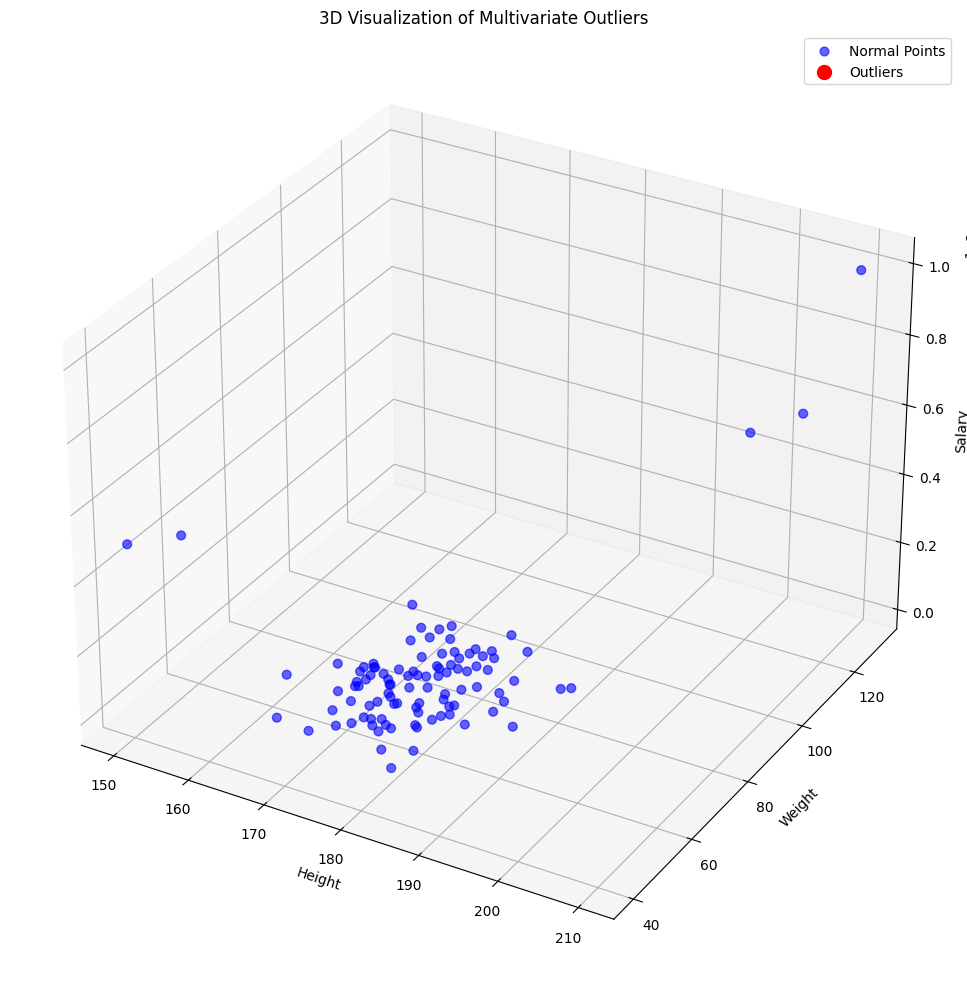

In [31]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


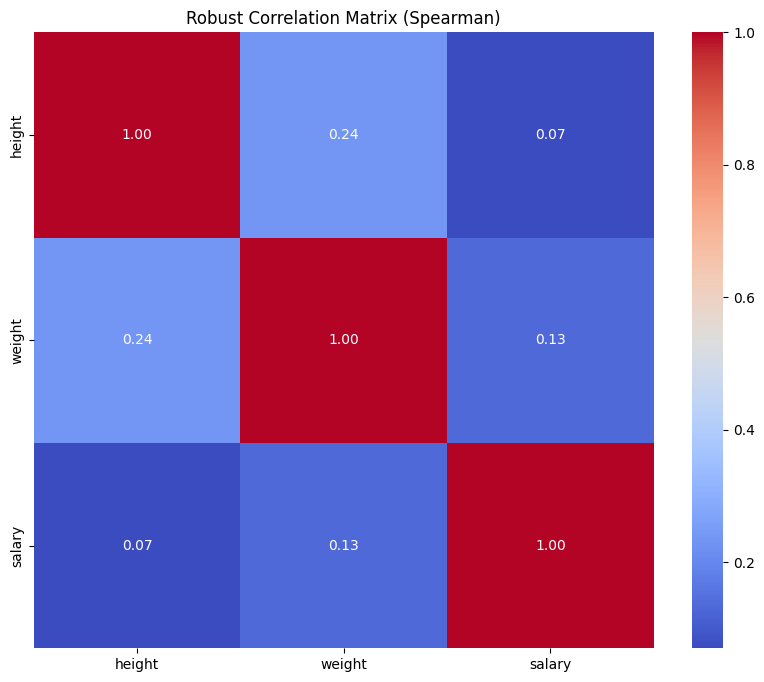

In [32]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [33]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [34]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)


In [35]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

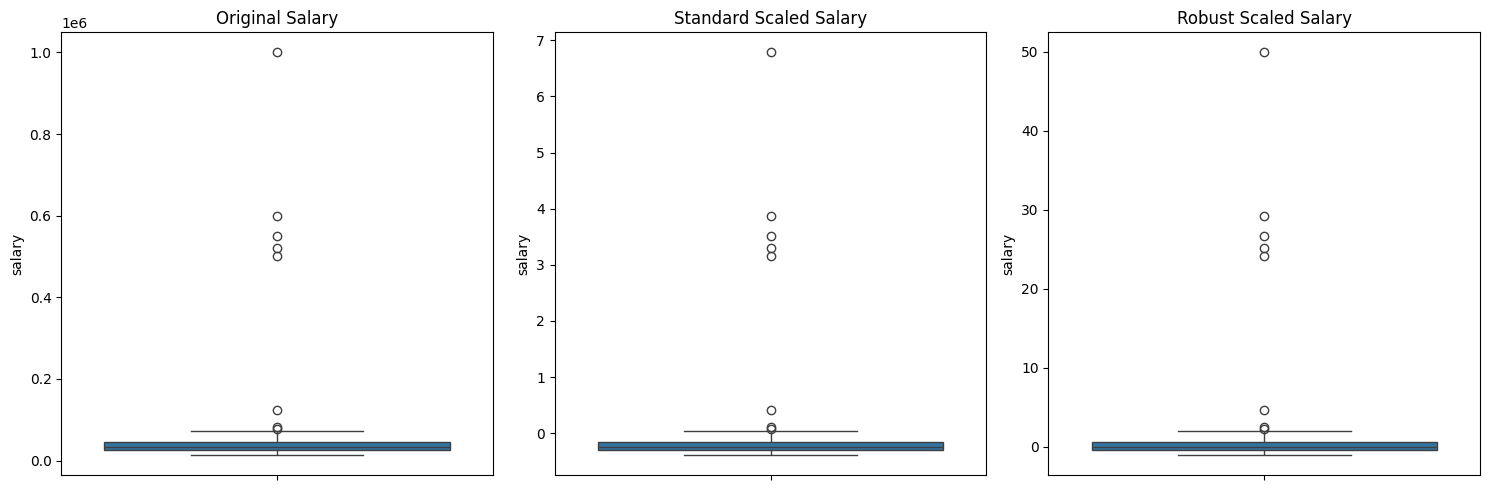

In [36]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [37]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [38]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.53x + 2.05')

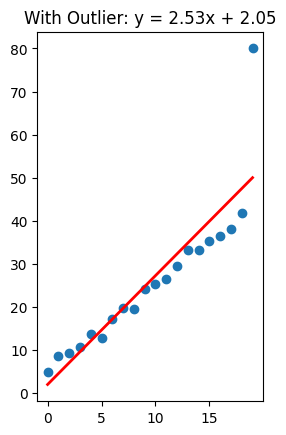

In [39]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


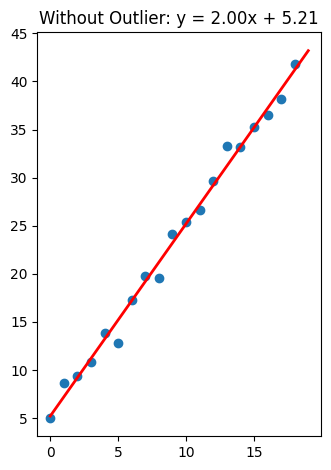

In [40]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis


In [ ]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [41]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


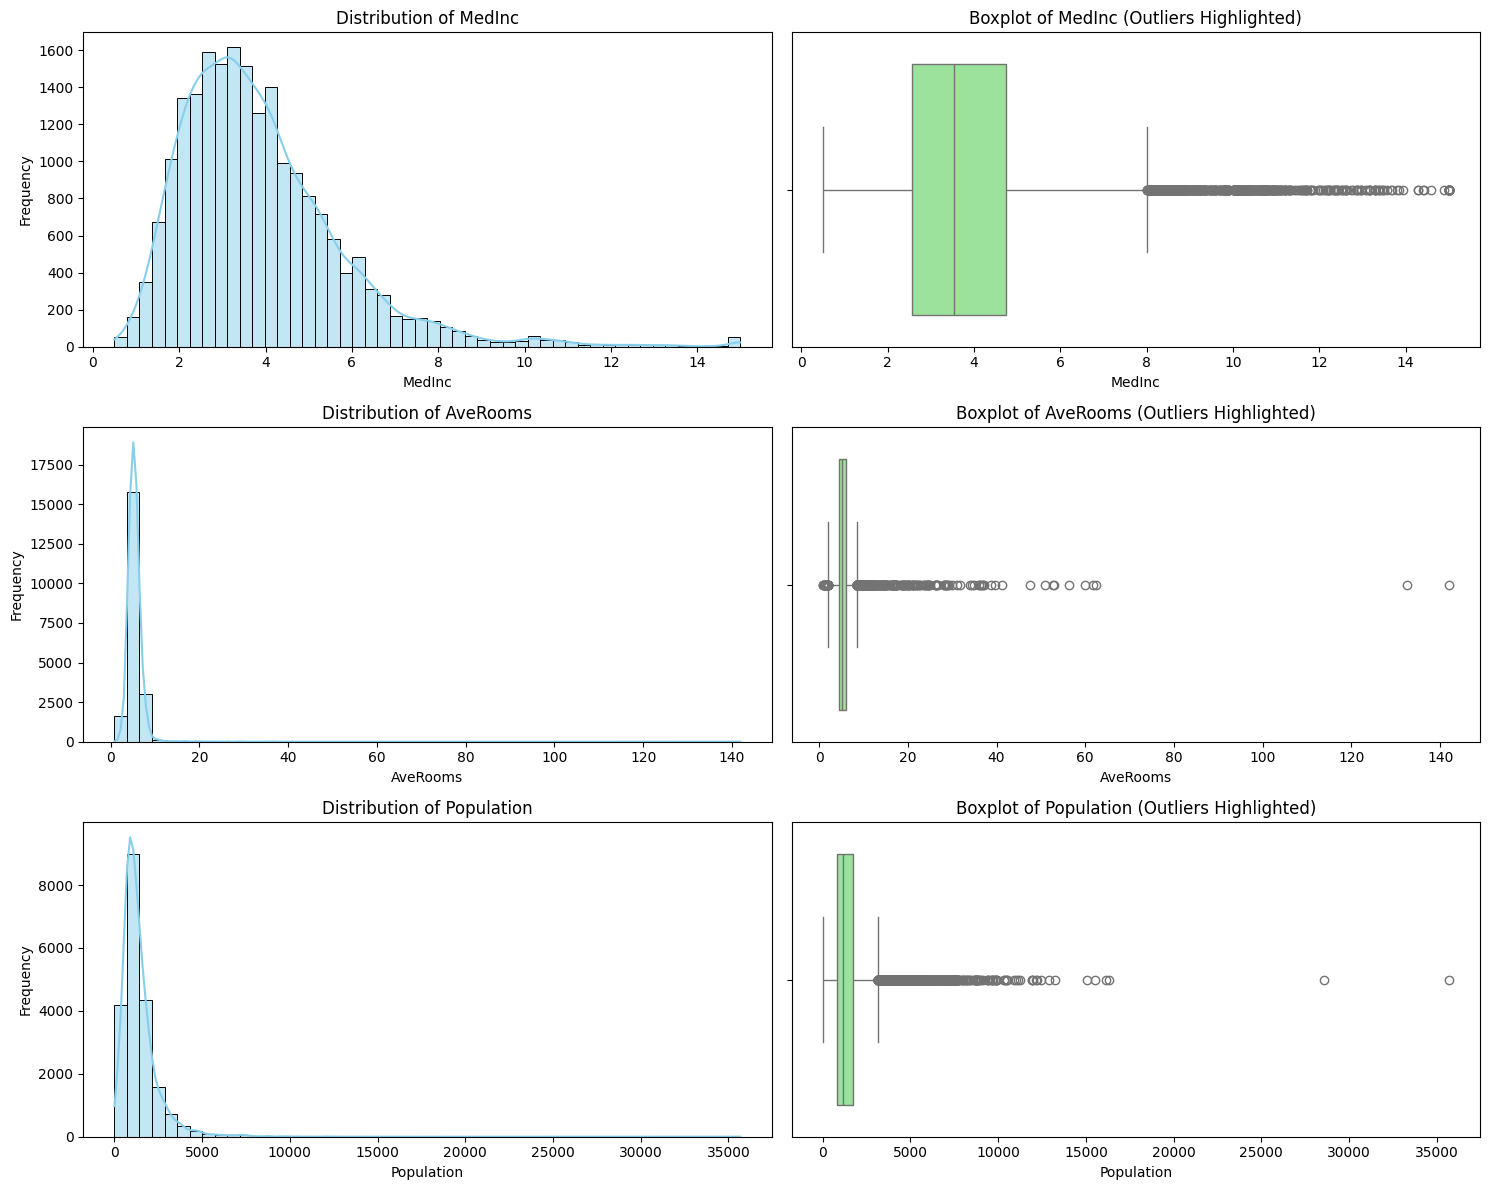

In [42]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# -----------------------------------------------------------

# Select 3 features that typically show interesting outliers
features_to_plot = ['MedInc', 'AveRooms', 'Population']

# Create a figure with a grid layout (3 rows, 2 columns)
plt.figure(figsize=(15, 12))

# Loop through each feature to create its plots
for i, feature in enumerate(features_to_plot):

    # 1. Histogram (Left column)
    # The math: 2*i + 1 places it in slots 1, 3, and 5
    plt.subplot(3, 2, 2*i + 1)
    sns.histplot(df[feature], bins=50, kde=True, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

    # 2. Box Plot (Right column)
    # The math: 2*i + 2 places it in slots 2, 4, and 6
    plt.subplot(3, 2, 2*i + 2)
    sns.boxplot(x=df[feature], color='lightgreen')
    plt.title(f'Boxplot of {feature} (Outliers Highlighted)')
    plt.xlabel(feature)

# Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [51]:
# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------

# We will use 'MedHouseVal' (Median House Value) as requested
target_feature = 'MedHouseVal'

# 1. Apply Z-score outlier detection
# (Using the detect_outliers_zscore function defined earlier in the notebook)
z_outlier_indices = detect_outliers_zscore(df[target_feature], threshold=3)

# 2. Apply IQR outlier detection
# (Using the detect_outliers_iqr function defined earlier in the notebook)
iqr_outlier_indices = detect_outliers_iqr(df[target_feature], factor=1.5)

# 3. Print the results to compare how each method performed
print(f"Outlier Analysis for: {target_feature}")
print("-" * 40)
print(f"Total records in dataset: {len(df)}")
print(f"Outliers flagged by Z-score (Threshold 3): {len(z_outlier_indices)}")
print(f"Outliers flagged by IQR (Factor 1.5): {len(iqr_outlier_indices)}")

# 4. Bonus: Let's see how many identical records BOTH methods flagged
consensus = set(z_outlier_indices).intersection(set(iqr_outlier_indices))
print(f"Outliers flagged by BOTH methods: {len(consensus)}")

Outlier Analysis for: MedHouseVal
----------------------------------------
Total records in dataset: 20640
Outliers flagged by Z-score (Threshold 3): 0
Outliers flagged by IQR (Factor 1.5): 1071
Outliers flagged by BOTH methods: 0


In [44]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------

# 1. Initialize the Isolation Forest model
# contamination=0.05 tells the model to expect 5% of the data to be outliers
# random_state=42 ensures you get the exact same results every time you run it
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# 2. Fit the model and predict anomalies on the feature set
# The fit_predict method automatically returns an array of 1s (normal) and -1s (outliers)
outlier_labels = iso_forest.fit_predict(X)

# 3. Create a binary mask where True represents an outlier (-1)
outlier_mask = (outlier_labels == -1)

# 4. Print the results to verify
total_outliers = outlier_mask.sum()
print("Isolation Forest Results:")
print("-" * 30)
print(f"Total records analyzed: {len(X)}")
print(f"Outliers detected (-1): {total_outliers}")
print(f"Actual contamination rate: {(total_outliers / len(X)) * 100:.2f}%")

Isolation Forest Results:
------------------------------
Total records analyzed: 20640
Outliers detected (-1): 1032
Actual contamination rate: 5.00%


In [45]:
# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------

# Setup: Since we are using California Housing, we use MedInc to predict MedHouseVal
X_col = 'MedInc'
y_col = 'MedHouseVal'

# Helper function to train and evaluate a model
def evaluate_regression(X_data, y_data, model_name):
    # Reshape X because scikit-learn expects a 2D array for features
    X_reshaped = X_data.values.reshape(-1, 1)

    # Train the model
    model = LinearRegression()
    model.fit(X_reshaped, y_data)

    # Make predictions and calculate metrics
    predictions = model.predict(X_reshaped)
    r2 = r2_score(y_data, predictions)
    coef = model.coef_[0]

    print(f"--- {model_name} ---")
    print(f"Data points: {len(X_data)}")
    print(f"Coefficient (Slope): {coef:.4f}")
    print(f"R-squared (Accuracy): {r2:.4f}\n")

    return model

print("LINEAR REGRESSION COMPARISON\n" + "="*30)

# 1. Model A: With ALL data
evaluate_regression(df[X_col], df[y_col], "Model A: All Data (With Outliers)")

# 2. Model B: After removing Z-score outliers
# (Re-calculating Z-score indices just in case)
z_indices = detect_outliers_zscore(df[X_col], threshold=3)
df_clean_z = df.drop(index=z_indices)
evaluate_regression(df_clean_z[X_col], df_clean_z[y_col], "Model B: Z-score Outliers Removed")

# 3. Model C: After removing Isolation Forest outliers
# (Using the mask from Exercise 3, we drop the rows where the mask is True)
df_clean_iso = df[~outlier_mask]
evaluate_regression(df_clean_iso[X_col], df_clean_iso[y_col], "Model C: Isolation Forest Outliers Removed")

LINEAR REGRESSION COMPARISON
--- Model A: All Data (With Outliers) ---
Data points: 20640
Coefficient (Slope): 0.4179
R-squared (Accuracy): 0.4734

--- Model B: Z-score Outliers Removed ---
Data points: 20295
Coefficient (Slope): 0.4521
R-squared (Accuracy): 0.4321

--- Model C: Isolation Forest Outliers Removed ---
Data points: 19608
Coefficient (Slope): 0.4459
R-squared (Accuracy): 0.4645



LinearRegression()

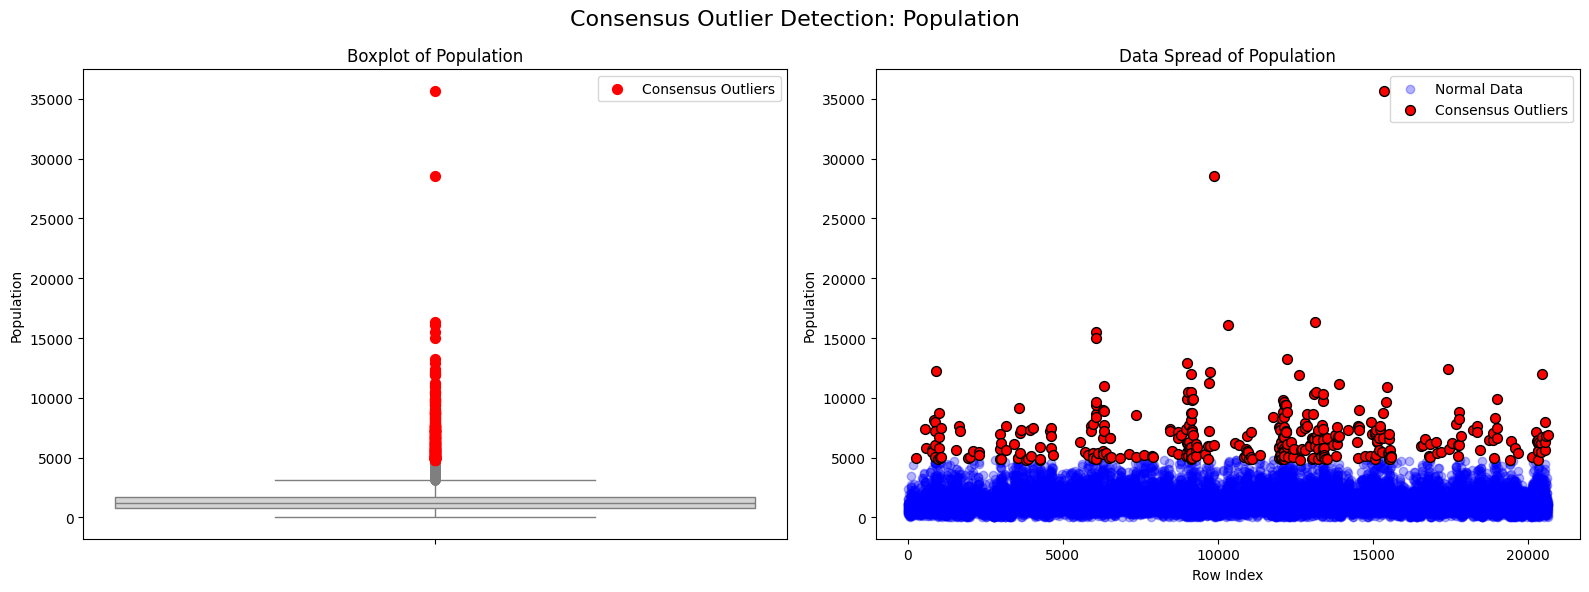

--- Outlier Detection Summary for 'Population' ---
Total Rows: 20640
Flagged by Z-score only: 0
Flagged by IQR only: 854
Consensus Outliers (Flagged by BOTH): 342



In [46]:
# EXERCISE 5: Create Your Own Outlier Detection Workflow
# -----------------------------------------------------

def custom_outlier_workflow(data, column_name):
    """
    Combines Z-score and IQR methods to find consensus outliers.
    Visualizes the results and returns the indices.
    """
    feature = data[column_name]

    # 1. Method A: Z-Score (Threshold = 3)
    z_scores = np.abs(stats.zscore(feature))
    z_outliers = set(np.where(z_scores > 3)[0])

    # 2. Method B: IQR (Factor = 1.5)
    q1, q3 = np.percentile(feature, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    iqr_outliers = set(np.where((feature < lower_bound) | (feature > upper_bound))[0])

    # 3. Find Consensus (Intersection of both sets)
    # This finds only the row indices that exist in BOTH lists
    consensus_outliers = list(z_outliers.intersection(iqr_outliers))
    consensus_outliers.sort() # Sort to keep the indices in order

    # 4. Visualization
    plt.figure(figsize=(16, 6))

    # Plot A: Boxplot with highlighted consensus outliers
    plt.subplot(1, 2, 1)
    sns.boxplot(y=feature, color='lightgray')
    plt.scatter(np.zeros_like(consensus_outliers), feature.iloc[consensus_outliers],
                color='red', s=50, label='Consensus Outliers', zorder=5)
    plt.title(f'Boxplot of {column_name}')
    plt.ylabel(column_name)
    plt.legend()

    # Plot B: Scatter plot to see the spread across the whole dataset
    plt.subplot(1, 2, 2)
    plt.scatter(range(len(feature)), feature, alpha=0.3, label='Normal Data', color='blue')
    plt.scatter(consensus_outliers, feature.iloc[consensus_outliers],
                color='red', s=50, label='Consensus Outliers', edgecolor='black')
    plt.title(f'Data Spread of {column_name}')
    plt.xlabel('Row Index')
    plt.ylabel(column_name)
    plt.legend()

    plt.suptitle(f'Consensus Outlier Detection: {column_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Print the summary report
    print(f"--- Outlier Detection Summary for '{column_name}' ---")
    print(f"Total Rows: {len(feature)}")
    print(f"Flagged by Z-score only: {len(z_outliers - iqr_outliers)}")
    print(f"Flagged by IQR only: {len(iqr_outliers - z_outliers)}")
    print(f"Consensus Outliers (Flagged by BOTH): {len(consensus_outliers)}\n")

    return consensus_outliers

# Run the workflow on the 'Population' column
consensus_indices = custom_outlier_workflow(df, 'Population')

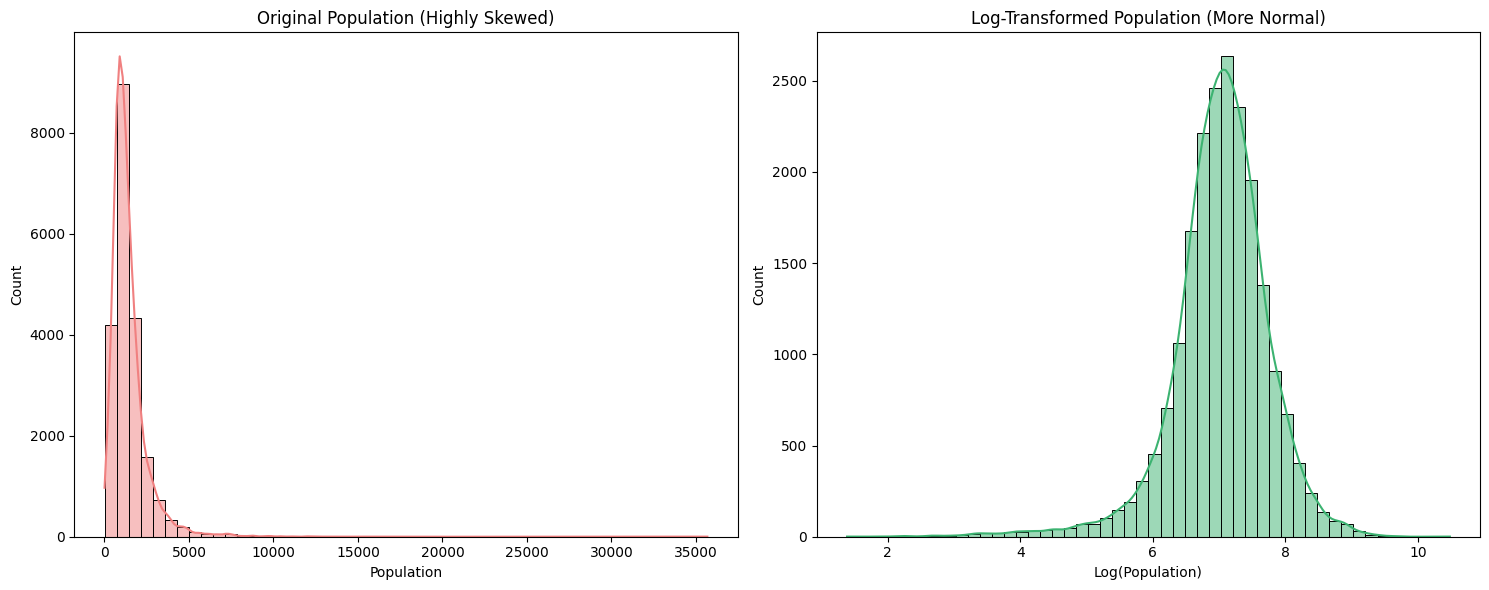

--- Skewness Comparison ---
Original Population Skewness: 4.94
Log Population Skewness: -1.04

*Note: Skewness closer to 0 indicates a perfect normal distribution. A high positive number means a heavy right tail.*


In [47]:
# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------

# APPROACH 1: Log Transformation
# The Population column has extreme right-skew (a few neighborhoods have massive populations).
# Applying a logarithm pulls those massive numbers in, creating a more normal "bell curve".
# We use np.log1p (which means log(1 + x)) to safely handle any potential zero values.
df['Population_Log'] = np.log1p(df['Population'])

# APPROACH 2: Binning / Discretization
# Instead of using exact income numbers (which are skewed by billionaires),
# we sort them into 5 distinct buckets (quantiles).
# Now, an extreme outlier just becomes part of the "Very High" bucket, completely neutralizing its mathematical pull.
df['Income_Bracket'] = pd.qcut(df['MedInc'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# VISUALIZATION: Compare the distribution before and after Log Transformation
plt.figure(figsize=(15, 6))

# Plot A: Original Data
plt.subplot(1, 2, 1)
sns.histplot(df['Population'], bins=50, kde=True, color='lightcoral')
plt.title('Original Population (Highly Skewed)')
plt.xlabel('Population')

# Plot B: Transformed Data
plt.subplot(1, 2, 2)
sns.histplot(df['Population_Log'], bins=50, kde=True, color='mediumseagreen')
plt.title('Log-Transformed Population (More Normal)')
plt.xlabel('Log(Population)')

plt.tight_layout()
plt.show()

# Print the mathematical proof (Skewness)
print("--- Skewness Comparison ---")
print(f"Original Population Skewness: {df['Population'].skew():.2f}")
print(f"Log Population Skewness: {df['Population_Log'].skew():.2f}")
print("\n*Note: Skewness closer to 0 indicates a perfect normal distribution. "
      "A high positive number means a heavy right tail.*")

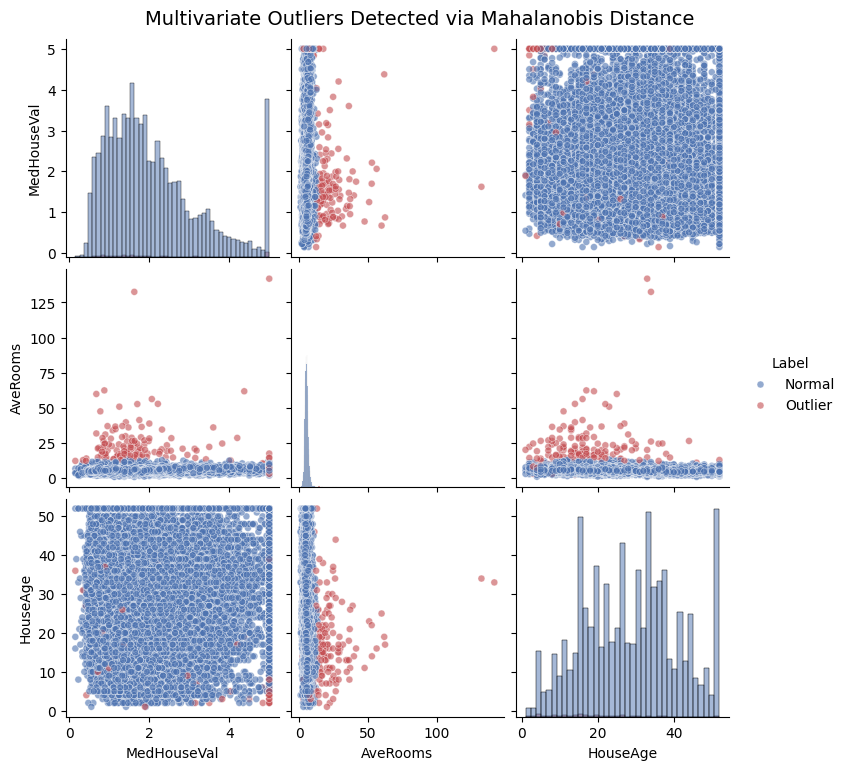

--- Multivariate Outlier Detection Summary ---
Features Analyzed: ['MedHouseVal', 'AveRooms', 'HouseAge']
Total Records: 20640
Chi-Squared Threshold (99%): 3.3682
Multivariate Outliers Detected: 165


In [52]:
# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------
from scipy.stats import chi2

# 1. Select a subset of features for the multivariate analysis
features = ['MedHouseVal', 'AveRooms', 'HouseAge']
data_subset = df[features]

# 2. Calculate the Mean Vector and Inverse Covariance Matrix
# These are the two key ingredients for Mahalanobis distance
mean_vector = np.mean(data_subset, axis=0)
covariance_matrix = np.cov(data_subset, rowvar=False)
inv_covariance_matrix = np.linalg.inv(covariance_matrix)

# 3. Define the Mahalanobis Distance calculation
def calculate_mahalanobis(row):
    # The formula: D^2 = (x - mean)^T * inv_cov * (x - mean)
    diff = row - mean_vector
    # We take the square root to get the actual distance
    return np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))

# Apply the calculation to every row in our dataset
mahalanobis_distances = data_subset.apply(calculate_mahalanobis, axis=1)

# 4. Determine the Statistical Threshold using Chi-Squared
# Because Mahalanobis distances follow a Chi-Squared distribution,
# we can mathematically draw a line at the 99th percentile (0.99)
degrees_of_freedom = len(features)
threshold = np.sqrt(chi2.ppf(0.99, df=degrees_of_freedom))

# 5. Flag the Outliers
outlier_mask = mahalanobis_distances > threshold

# 6. Visualization: Scatter Plot Matrix (Pairplot)
# Create a temporary dataframe just for plotting
plot_df = data_subset.copy()
plot_df['Label'] = np.where(outlier_mask, 'Outlier', 'Normal')

# Draw the pairplot
sns.pairplot(plot_df,
             hue='Label',
             palette={'Normal': '#4C72B0', 'Outlier': '#C44E52'},
             plot_kws={'alpha': 0.6, 's': 25},
             diag_kind='hist')

plt.suptitle('Multivariate Outliers Detected via Mahalanobis Distance', y=1.02, fontsize=14)
plt.show()

# Print the final report
print("--- Multivariate Outlier Detection Summary ---")
print(f"Features Analyzed: {features}")
print(f"Total Records: {len(data_subset)}")
print(f"Chi-Squared Threshold (99%): {threshold:.4f}")
print(f"Multivariate Outliers Detected: {outlier_mask.sum()}")